In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import numpy as np

# Point this to exactly where you uploaded the file in your Drive
file_path = '/content/drive/MyDrive/ML_Projects/music_data.npz'

print("Loading data from Drive...")
loaded_data = np.load(file_path)

# Extract the arrays
data = loaded_data['data']
labels = loaded_data['labels']

print("Data shape:", data.shape)
print("Labels shape:", labels.shape)
print("Ready to build the Neural Network!")

Loading data from Drive...
Data shape: (14975, 210, 210, 1)
Labels shape: (14975,)
Ready to build the Neural Network!


#OUR CODE PROCEEDS

In [6]:
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import sklearn
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Conv2D,MaxPool2D,Flatten,Dense,Dropout
from tensorflow.keras.optimizers import Adam

In [37]:
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import sklearn
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Conv2D,MaxPool2D,Flatten,Dense,Dropout
from tensorflow.keras.optimizers import Adam



classes = ['blues' , 'classical' , 'country' , 'disco' , 'hiphop' , 'jazz' , 'metal' , 'pop' , 'reggae' , 'rock']
labels = to_categorical(labels,num_classes = len(classes))


NameError: name 'labels' is not defined

# Splitting data into training and testing

In [9]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test = train_test_split(data,labels,test_size=0.2,random_state=42)


#Building ***Model***

In [10]:
model = tf.keras.models.Sequential()

In [11]:
model.add(Conv2D(filters=32 , kernel_size=3,padding='same',activation='relu',input_shape=X_train[0].shape))
model.add(Conv2D(filters=32 , kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2 , strides=2))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.add(Conv2D(filters=64 , kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=64 , kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2 , strides=2))

In [13]:
model.add(Conv2D(filters=128 , kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=128 , kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2 , strides=2))

In [14]:
model.add(Dropout(0.3))

In [15]:
model.add(Conv2D(filters=256 , kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=256 , kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2 , strides=2))

In [16]:
model.add(Conv2D(filters=512 , kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=512 , kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2 , strides=2))

In [17]:
model.add(Dropout(0.3))

In [18]:
model.add(Flatten())

In [19]:
model.add(Dense(units=1200,activation='relu'))

In [20]:
model.add(Dropout(0.45))

In [21]:
#Output layer
model.add(Dense(units=len(classes),activation='softmax'))

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 210, 210, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 208, 208, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 104, 104, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 104, 104, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 102, 102, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 51, 51, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 51, 51, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 49, 49, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 22, 22, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 11, 11, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 11, 11, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1200)           │     9,831,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        12,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,555,258 (55.52 MB)

 Trainable params: 14,555,258 (55.52 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
#compile the model
model.compile(optimizer=Adam(learning_rate=0.0001) , loss='categorical_crossentropy' , metrics=['accuracy'])

In [24]:
#Training model
training_history = model.fit(X_train , Y_train , epochs=30 , batch_size=32 , validation_data=(X_test,Y_test))

Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 96s 196ms/step - accuracy: 0.3259 - loss: 1.8434 - val_accuracy: 0.4905 - val_loss: 1.4255
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 57s 152ms/step - accuracy: 0.5316 - loss: 1.3222 - val_accuracy: 0.6224 - val_loss: 1.0876
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 57s 151ms/step - accuracy: 0.6426 - loss: 1.0377 - val_accuracy: 0.6668 - val_loss: 0.9985
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 57s 151ms/step - accuracy: 0.7086 - loss: 0.8515 - val_accuracy: 0.7075 - val_loss: 0.8618
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 57s 151ms/step - accuracy: 0.7674 - loss: 0.6872 - val_accuracy: 0.7603 - val_loss: 0.6919
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 57s 151ms/step - accuracy: 0.8090 - loss: 0.5634 - val_accuracy: 0.8184 - val_loss: 0.5614
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 57s 151ms/step - accuracy: 0.8427 - loss: 0.4651 - val_accuracy: 0.8290 - val_loss: 0.5202
Epoch 8/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 57s 151ms/step - accuracy: 0.8693 - loss: 0

In [25]:
model.save("Trained_model.h5")

In [26]:


model.save("/content/drive/MyDrive/ML_Projects/Trained_model.keras")

print("Model saved successfully to Google Drive in the new format!")

Model saved successfully to Google Drive in the new format!


In [27]:
model.save("Trained_model.keras")

In [28]:
training_history.history


{'accuracy': [0.32587647438049316,
  0.5316360592842102,
  0.642570972442627,
  0.7085976600646973,
  0.7674457430839539,
  0.8090150356292725,
  0.8426544070243835,
  0.8692821264266968,
  0.8960767984390259,
  0.9105175137519836,
  0.9263772964477539,
  0.9378130435943604,
  0.9451586008071899,
  0.9508347511291504,
  0.9605175256729126,
  0.9613522291183472,
  0.9663606286048889,
  0.972287118434906,
  0.971953272819519,
  0.9792988300323486,
  0.9760434031486511,
  0.9811352491378784,
  0.9734557867050171,
  0.985308825969696,
  0.9822203516960144,
  0.9829716086387634,
  0.9833889603614807,
  0.9861435890197754,
  0.9849749803543091,
  0.9900667667388916],
 'loss': [1.8433623313903809,
  1.3221843242645264,
  1.037695050239563,
  0.8514638543128967,
  0.6871782541275024,
  0.5633789300918579,
  0.4650993347167969,
  0.3824646770954132,
  0.3136458992958069,
  0.261277437210083,
  0.21840280294418335,
  0.17993026971817017,
  0.16275876760482788,
  0.14331106841564178,
  0.12196068

In [29]:
import json
with open('training_hist.json','w') as f :
  json.dump(training_history.history,f)

In [30]:
import pandas as pd
history_df = pd.DataFrame(training_history.history)
history_df.to_csv("/content/drive/MyDrive/ML_Projects/training_history.csv", index=False)

print("History saved permanently to Google Drive!")

History saved permanently to Google Drive!


In [31]:
import numpy as np

# Make sure this path points to your ML_Project folder in Drive!
save_path = '/content/drive/MyDrive/ML_Projects/split_data.npz'

print("Saving train/test splits to Google Drive...")

# We use np.savez_compressed to save multiple arrays in one file
np.savez_compressed(save_path,
                    X_train=X_train,
                    X_test=X_test,
                    Y_train=Y_train,
                    Y_test=Y_test)

print("Data saved successfully! You can now safely close Colab.")

Saving train/test splits to Google Drive...
Data saved successfully! You can now safely close Colab.


In [32]:
import numpy as np
from google.colab import files

# 1. Save the four arrays directly to Colab's temporary files
file_name = "music_split_data.npz"

np.savez_compressed(file_name,
                    X_train=X_train,
                    X_test=X_test,
                    Y_train=Y_train,
                    Y_test=Y_test)

print(f"Successfully saved {file_name} to Colab workspace!")

Successfully saved music_split_data.npz to Colab workspace!


##Loading model , training_history and X_test , X_train , Y_test , Y_train

In [10]:
import tensorflow as tf
import numpy as np
import pandas as pd
from google.colab import drive

print("\nLoading data...")
# Make sure this matches the folder name you used!
data_path = '/content/drive/MyDrive/ML_Projects/split_data.npz'
loaded_data = np.load(data_path)

X_train = loaded_data['X_train']
X_test = loaded_data['X_test']
Y_train = loaded_data['Y_train']
Y_test = loaded_data['Y_test']

print("✅ Data loaded! X_train shape:", X_train.shape)

# ---------------------------------------------------------
# Step 3: Load the Trained Model
# ---------------------------------------------------------
print("\nWaking up the AI...")
model_path = '/content/drive/MyDrive/ML_Projects/Trained_model.keras'
model = tf.keras.models.load_model(model_path)

print("✅ Model loaded successfully!")

# ---------------------------------------------------------
# Step 4: Load the Training History
# ---------------------------------------------------------
print("\nLoading training history...")
history_path = '/content/drive/MyDrive/ML_Projects/training_history.csv'
training_history = pd.read_csv(history_path)

print("✅ History loaded!")


Loading data...
✅ Data loaded! X_train shape: (11980, 210, 210, 1)

Waking up the AI...


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 26 variables whereas the saved optimizer has 50 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


✅ Model loaded successfully!

Loading training history...
✅ History loaded!


In [12]:
#Reloading model variable
model = tf.keras.models.load_model("Trained_model.h5")
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 210, 210, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 208, 208, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 104, 104, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 104, 104, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 102, 102, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 51, 51, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 51, 51, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 49, 49, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 22, 22, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 11, 11, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 11, 11, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1200)           │     9,831,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        12,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,110,518 (111.05 MB)

 Trainable params: 14,555,258 (55.52 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 14,555,260 (55.52 MB)

In [ ]:
#for loading training_history
import json
with open("training_hist.json",'r') as json_file:
  training_history = json.load(json_file)


In [14]:
training_history

,accuracy,loss,val_accuracy,val_loss
0,0.325876,1.843362,0.490484,1.425451
1,0.531636,1.322184,0.622371,1.087605
2,0.642571,1.037695,0.666778,0.998548
3,0.708598,0.851464,0.707512,0.861771
4,0.767446,0.687178,0.760267,0.691932
5,0.809015,0.563379,0.818364,0.561418
6,0.842654,0.465099,0.829048,0.520191
7,0.869282,0.382465,0.867780,0.414231
8,0.896077,0.313646,0.853756,0.468441
9,0.910518,0.261277,0.878130,0.392324


#Model Evaluation

In [15]:
#model evaluation on train set
train_loss , train_accuracy = model.evaluate(X_train,Y_train)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1834s 5s/step - accuracy: 0.9895 - loss: 0.0325


In [16]:
train_loss , train_accuracy

(0.03250407427549362, 0.9894824624061584)

In [18]:
#model evaluation on validation set
val_loss , val_accuracy = model.evaluate(X_test,Y_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 474s 5s/step - accuracy: 0.9132 - loss: 0.3657


In [19]:
val_loss , val_accuracy

(0.36574113368988037, 0.913188636302948)

In [21]:
#training_history.history['loss']
training_history['loss']

,loss
0,1.843362
1,1.322184
2,1.037695
3,0.851464
4,0.687178
5,0.563379
6,0.465099
7,0.382465
8,0.313646
9,0.261277


##Accuracy and Loss Visualization

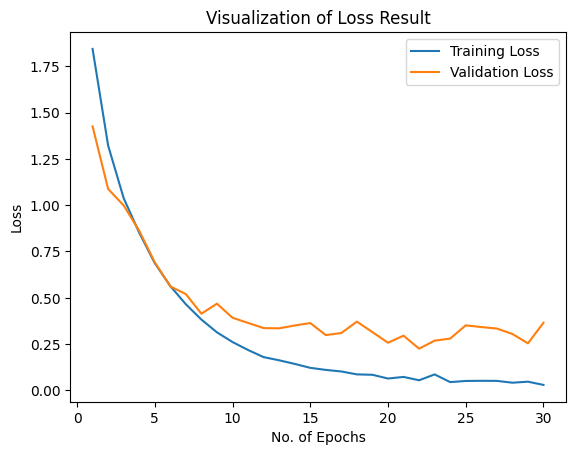

In [22]:
#Visualization of loss
epochs = [i for i in range(1,31)]

plt.plot(epochs,training_history['loss'],label="Training Loss")
plt.plot(epochs,training_history['val_loss'],label="Validation Loss")

#plt.plot(epochs,training_history.history['loss'],label="Training Loss")
#plt.plot(epochs,training_history.history['val_loss'],label="Validation Loss")

plt.xlabel("No. of Epochs")
plt.ylabel("Loss")
plt.title("Visualization of Loss Result")
plt.legend()
plt.show()

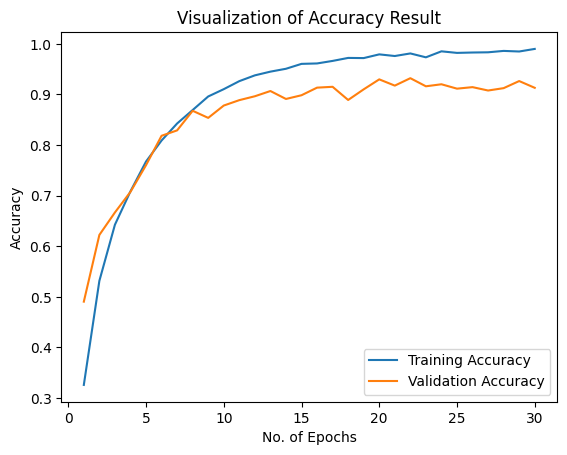

In [23]:
#Visualization of Accuracy
epochs = [i for i in range(1,31)]
plt.plot(epochs,training_history['accuracy'],label="Training Accuracy")
plt.plot(epochs,training_history['val_accuracy'],label="Validation Accuracy")

#plt.plot(epochs,training_history.history['accuracy'],label="Training Accuracy")
#plt.plot(epochs,training_history.history['val_accuracy'],label="Validation Accuracy")
plt.xlabel("No. of Epochs")
plt.ylabel("Accuracy")
plt.title("Visualization of Accuracy Result")
plt.legend()
plt.show()

##Precision , Recall , Confusion Matrix - Model Evaluation -||

In [24]:
X_test

array([[[[5.60455024e-03],
         [6.73692720e-03],
         [6.43991912e-03],
         ...,
         [2.47470010e-02],
         [2.22500637e-02],
         [2.08734479e-02]],

        [[5.48363710e-03],
         [7.93092605e-03],
         [6.59776805e-03],
         ...,
         [2.04626694e-02],
         [2.25015935e-02],
         [3.30719091e-02]],

        [[5.50844567e-03],
         [9.76992305e-03],
         [6.87352056e-03],
         ...,
         [3.82319130e-02],
         [5.73372170e-02],
         [8.73312503e-02]],

        ...,

        [[1.36797426e-05],
         [9.09348728e-06],
         [2.41339803e-05],
         ...,
         [5.83457993e-04],
         [2.37415923e-04],
         [8.44288734e-05]],

        [[1.37508969e-05],
         [9.29902490e-06],
         [2.87853054e-05],
         ...,
         [7.48652383e-04],
         [2.83553178e-04],
         [9.95616429e-05]],

        [[1.38211817e-05],
         [9.44570911e-06],
         [3.19068531e-05],
         ...,
 

In [25]:
y_pred = model.predict(X_test)
y_pred

94/94 ━━━━━━━━━━━━━━━━━━━━ 454s 5s/step


array([[1.8603509e-04, 5.3135103e-05, 1.5941421e-02, ..., 9.4639599e-01,
        9.6449006e-04, 2.0635556e-03],
       [1.5586074e-18, 6.0941158e-22, 1.8433146e-21, ..., 2.8456466e-25,
        1.3239832e-20, 2.1080683e-10],
       [8.9756687e-17, 2.6018508e-13, 1.9015804e-13, ..., 7.0404321e-14,
        3.8368276e-15, 4.4687199e-06],
       ...,
       [9.9999952e-01, 3.3647255e-18, 1.0485160e-08, ..., 9.8875316e-15,
        2.8418985e-13, 2.7729706e-07],
       [1.1594171e-06, 9.9928868e-01, 1.0079755e-04, ..., 1.5129239e-04,
        5.3950673e-05, 6.4389897e-05],
       [3.5517857e-07, 2.6793081e-09, 3.3423696e-08, ..., 2.1049126e-04,
        1.7004778e-06, 2.2796841e-05]], dtype=float32)

In [26]:
predicted_categories = np.argmax(y_pred,axis=1)
predicted_categories

array([7, 6, 6, ..., 0, 1, 4])

In [27]:
Y_test

array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [28]:
true_categories = np.argmax(Y_test,axis=1)
true_categories

array([7, 6, 6, ..., 0, 1, 4])

In [30]:
classes

['blues',
 'classical',
 'country',
 'disco',
 'hiphop',
 'jazz',
 'metal',
 'pop',
 'reggae',
 'rock']

In [31]:
from sklearn.metrics import confusion_matrix,classification_report
cm = confusion_matrix(true_categories , predicted_categories)
#precision Recall F1score

print(classification_report(true_categories,predicted_categories,target_names=classes))


              precision    recall  f1-score   support

       blues       0.97      0.91      0.94       302
   classical       0.85      0.99      0.91       298
     country       0.91      0.80      0.85       317
       disco       0.93      0.96      0.94       312
      hiphop       0.94      0.94      0.94       277
        jazz       0.98      0.84      0.90       311
       metal       0.92      0.99      0.96       302
         pop       0.89      0.93      0.91       289
      reggae       0.98      0.89      0.93       296
        rock       0.81      0.89      0.85       291

    accuracy                           0.91      2995
   macro avg       0.92      0.91      0.91      2995
weighted avg       0.92      0.91      0.91      2995



##Confusion Matrix Visualization

In [32]:
cm

array([[276,   0,   9,   3,   3,   1,   0,   4,   1,   5],
       [  0, 296,   0,   0,   0,   0,   0,   0,   0,   2],
       [  4,   5, 254,   4,   0,   3,   1,   9,   1,  36],
       [  1,   3,   0, 299,   2,   0,   0,   5,   0,   2],
       [  0,   1,   0,   2, 259,   0,   9,   3,   0,   3],
       [  2,  34,  11,   0,   0, 260,   0,   1,   0,   3],
       [  0,   0,   0,   0,   0,   0, 300,   0,   0,   2],
       [  0,   6,   1,   1,   6,   0,   0, 269,   2,   4],
       [  2,   1,   3,   6,   5,   1,   2,   8, 264,   4],
       [  1,   4,   1,   8,   2,   0,  14,   2,   1, 258]])

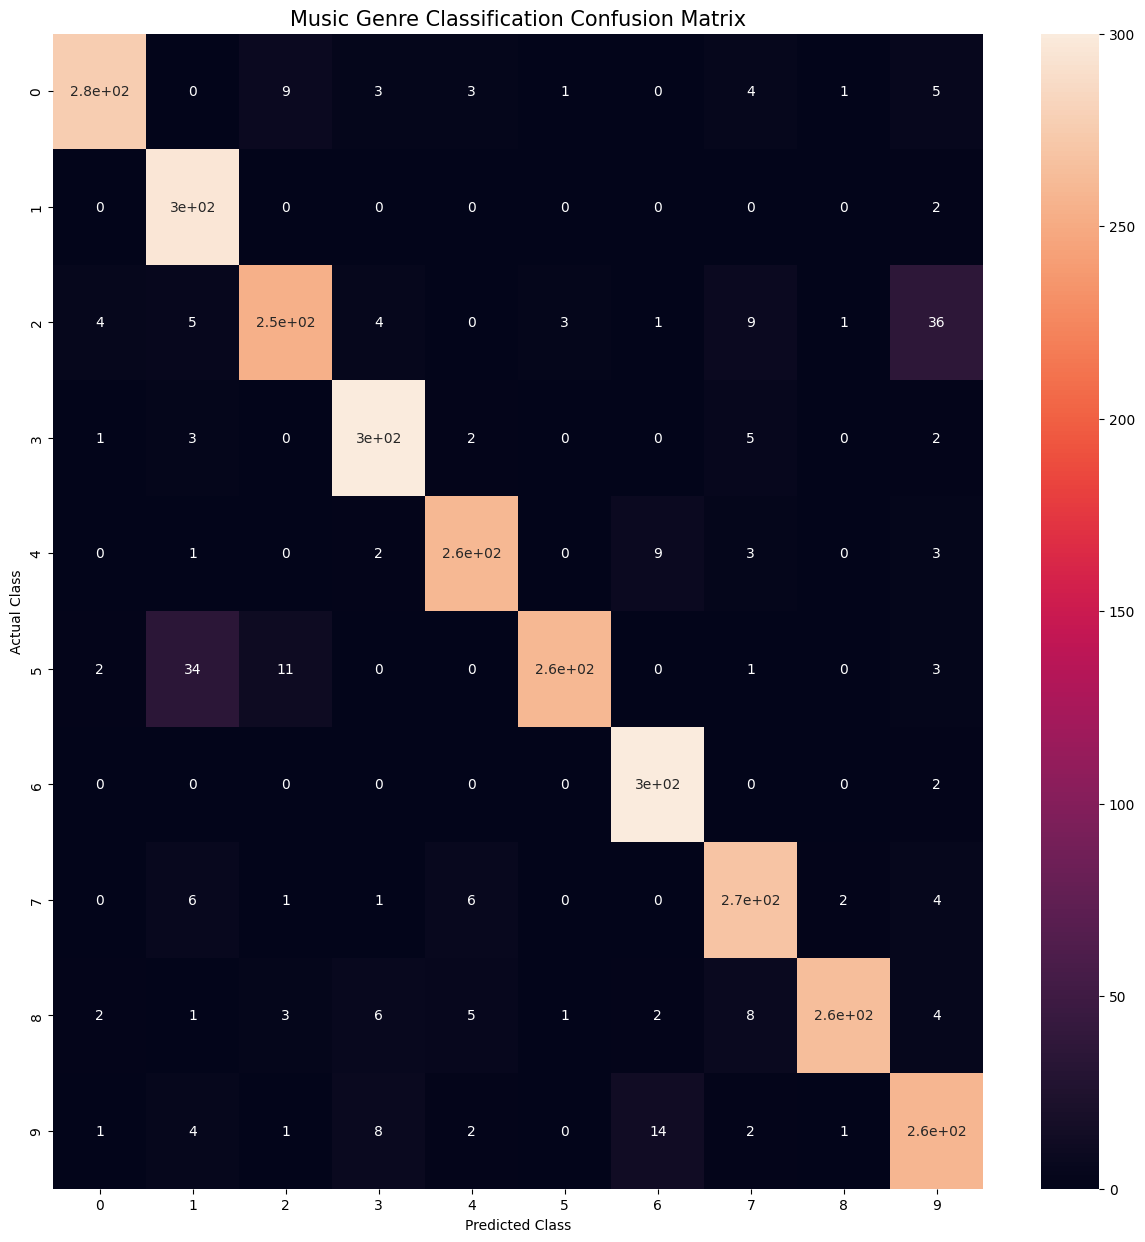

In [36]:
import seaborn as sns
plt.figure(figsize=(15,15))
sns.heatmap(cm,annot=True,annot_kws={"size":10})
plt.xlabel("Predicted Class",fontsize=10)
plt.ylabel("Actual Class",fontsize=10)
plt.title("Music Genre Classification Confusion Matrix",fontsize=15)
plt.show()